# Tesla Deliveries ML Pipeline (2015-2025)

This notebook implements an end-to-end machine learning pipeline on the provided Tesla delivery, production, and price dataset. The goal is to predict `Estimated_Deliveries` using time, region, model, price, production, battery, range, emissions, and charging infrastructure signals.

## Pipeline Scope

- Data loading and validation
- Exploratory data analysis (EDA)
- Feature engineering
- Preprocessing for numeric and categorical features
- Regression model comparison
- Hyperparameter tuning with time-series cross-validation
- Test-set evaluation and prediction export

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from tesla_ml_pipeline import DATA_PATH, OUTPUT_DIR, engineer_features, load_data, train_pipeline

In [2]:
raw_df = load_data(DATA_PATH)
raw_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")
display(raw_df.info())
raw_df.isna().sum()

Rows: 2,640
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


None

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [4]:
raw_df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


## Feature Engineering

The pipeline adds calendar features, seasonal month encodings, price efficiency, range efficiency, and charging-station density. It avoids target-derived features so the test performance remains realistic.

In [5]:
featured_df = engineer_features(raw_df)
featured_df[[
    "Date", "Year", "Month", "Quarter", "Region", "Model",
    "Estimated_Deliveries", "Avg_Price_USD", "Price_Per_kWh",
    "Range_Per_kWh", "Stations_Per_1000_Production"
]].head()

,Date,Year,Month,Quarter,Region,Model,Estimated_Deliveries,Avg_Price_USD,Price_Per_kWh,Range_Per_kWh,Stations_Per_1000_Production
0,2015-01-01,2015,1,1,Asia,Model Y,12446,55183.13,919.718833,5.666667,316.168527
1,2015-01-01,2015,1,1,Middle East,Model 3,11446,89289.40,892.894000,5.880000,699.890213
2,2015-01-01,2015,1,1,Middle East,Cybertruck,8803,102888.58,1714.809667,5.600000,419.841610
3,2015-01-01,2015,1,1,North America,Cybertruck,6367,104962.32,1280.028293,5.597561,1348.132902
4,2015-01-01,2015,1,1,Asia,Model 3,8795,87988.73,1073.033293,5.560976,1377.632297


## Train, Tune, and Evaluate

The script uses a time-aware split: earlier records train the models and the latest records are held out for testing. Candidate regressors include Ridge Regression, Random Forest, and Gradient Boosting. Hyperparameter tuning uses `TimeSeriesSplit`.

In [6]:
metrics_df, best_model, predictions_df = train_pipeline()
metrics_df

,model,mae,rmse,r2,best_params
0,Ridge,321.253705,391.244765,0.988595,NaN
4,Tuned Ridge,321.678267,391.504288,0.988580,{'model__alpha': 0.1}
1,Gradient Boosting,332.930923,405.306424,0.987760,NaN
2,Random Forest,329.042519,408.852634,0.987545,NaN
3,Tuned Random Forest,329.357817,409.110408,0.987530,"{'model__max_depth': None, 'model__min_samples..."


In [7]:
predictions_df.head(10)

,Date,Region,Model,Avg_Price_USD,Production_Units,Estimated_Deliveries,Predicted_Deliveries,Residual
2120,2023-11-01,Asia,Model X,114083.11,17800,15680,16498.807305,-818.807305
2121,2023-11-01,Europe,Model X,52155.06,12413,11323,11559.853072,-236.853072
2122,2023-11-01,Europe,Model Y,119313.43,12683,11523,11675.861214,-152.861214
2123,2023-11-01,Asia,Model Y,76864.18,12414,12368,11652.714464,715.285536
2124,2023-11-01,Middle East,Model Y,85715.12,11422,11111,10690.102479,420.897521
2125,2023-11-01,Asia,Model S,68562.66,12297,12065,11445.404862,619.595138
2126,2023-11-01,Europe,Cybertruck,94806.33,16023,15370,15034.837120,335.162880
2127,2023-11-01,North America,Cybertruck,87376.96,12577,11986,11608.889863,377.110137
2128,2023-11-01,North America,Model X,71688.78,6034,5365,5785.068194,-420.068194
2129,2023-11-01,Europe,Model 3,88815.88,12068,10577,11105.106228,-528.106228


## Saved EDA and Model Outputs

In [8]:
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path)

outputs\actual_vs_predicted.png
outputs\correlation_heatmap.png
outputs\deliveries_by_model_region.csv
outputs\deliveries_price_trend.png
outputs\eda_summary.csv
outputs\final_model_metrics.csv
outputs\model_comparison.csv
outputs\tesla_delivery_model.joblib
outputs\test_predictions.csv


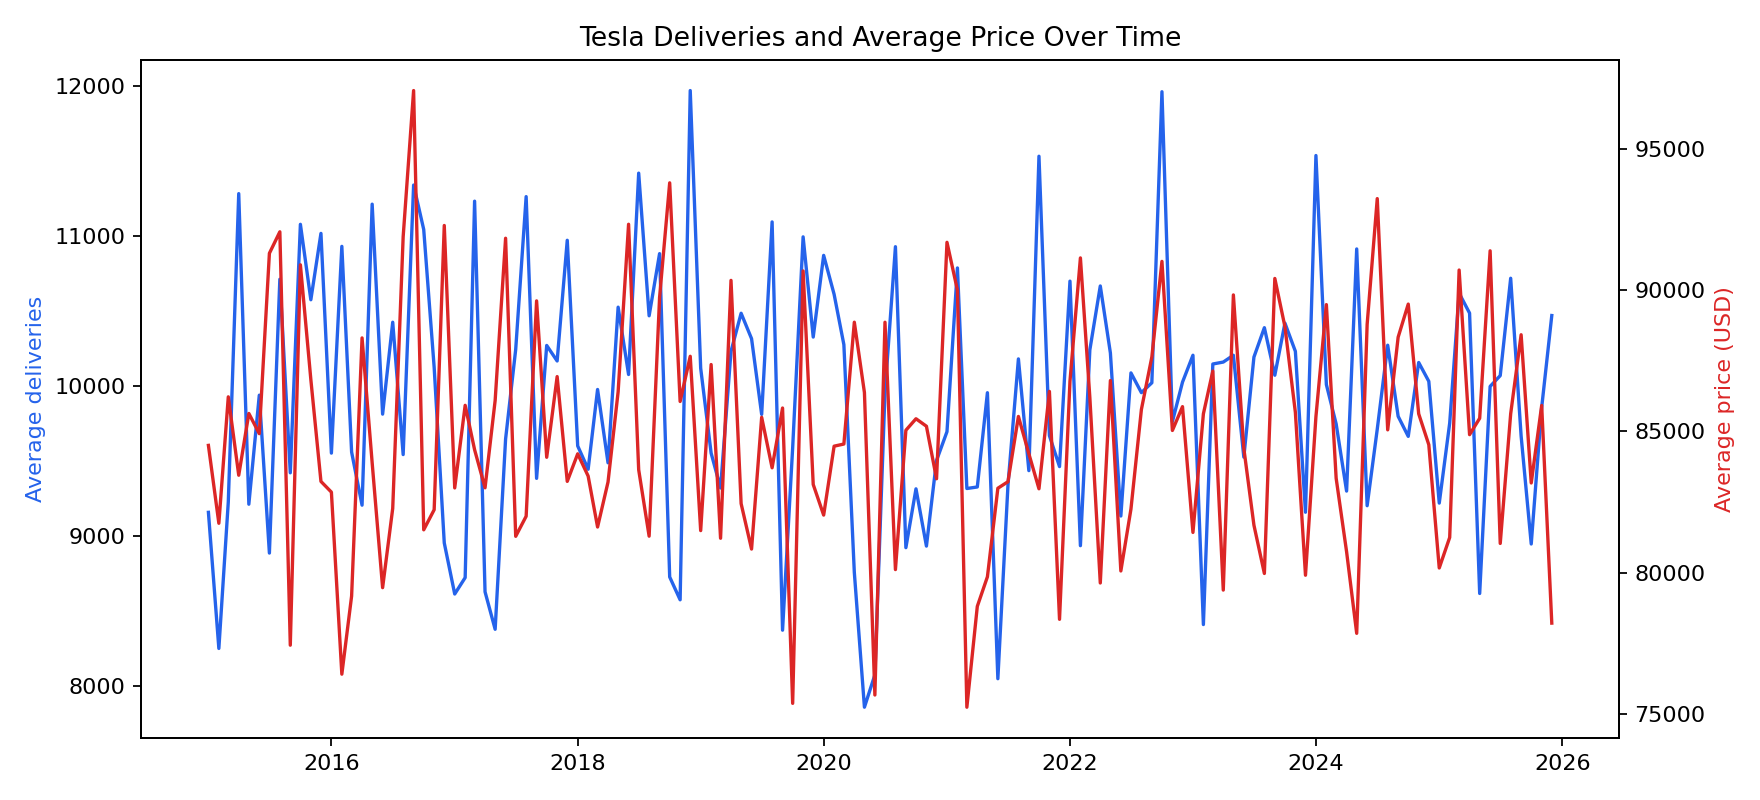

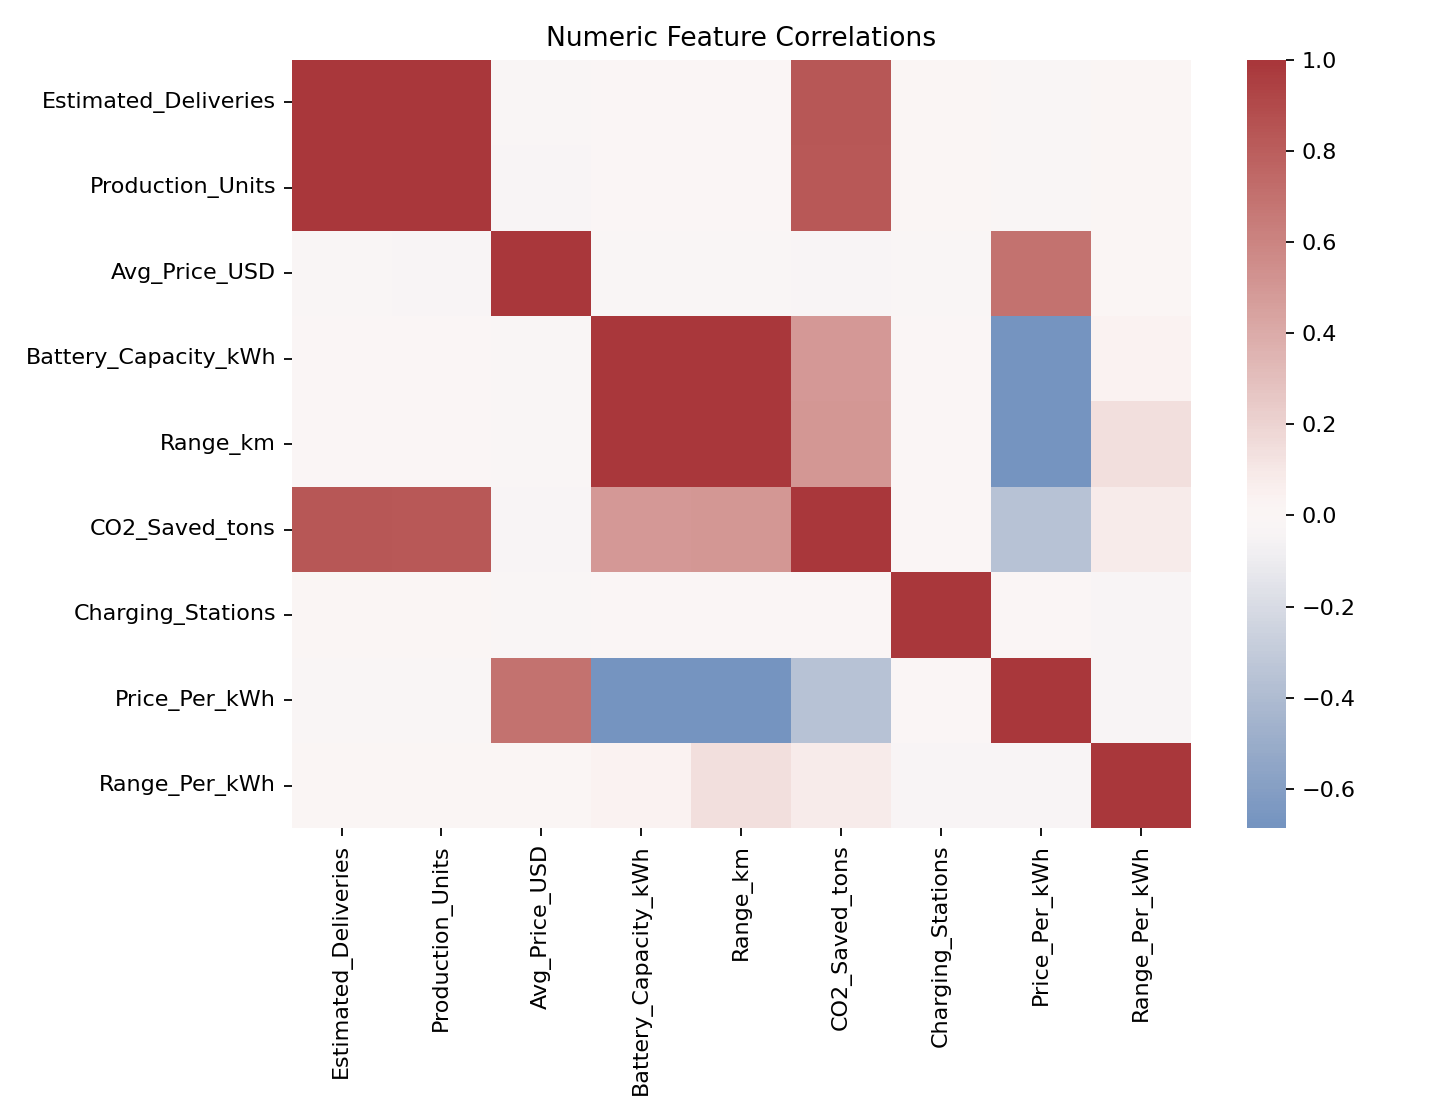

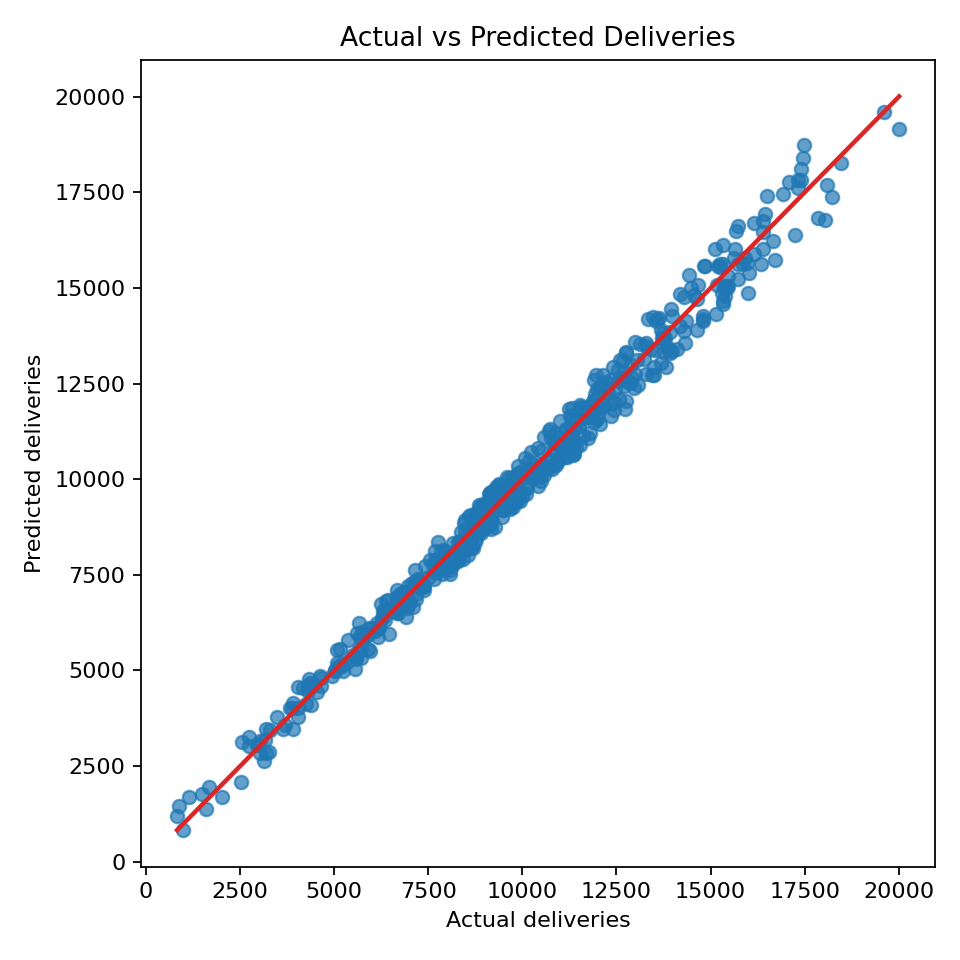

In [9]:
display(Image(filename=str(OUTPUT_DIR / "deliveries_price_trend.png")))
display(Image(filename=str(OUTPUT_DIR / "correlation_heatmap.png")))
display(Image(filename=str(OUTPUT_DIR / "actual_vs_predicted.png")))

## Conclusion

The final pipeline produces a reusable trained model, prediction file, model comparison metrics, and EDA visuals. The best model can be loaded from `outputs/tesla_delivery_model.joblib` for future inference.